### Decision Trees (Entscheidungsbäume)

[Video](https://youtu.be/nEBac-B231E) - [Video2](https://youtu.be/Ev3geu5DZxU)

#### Gini Impurity Index
Der Gini Impurity Index wird verwendet als Maß für die Vielfalt (diversity) innerhalb einer Sammlung von Objekten.

Der Gini Impurity Index ist die Wahrscheinlichkeit, bei einer Ziehung (mit Zurücklegen) von zwei Elementen, verschiedenartige Elemente zu ziehen.

Beispiel: Gegeben Urne mit 7 blauen und 3 roten Kugeln. Wie groß ist die Wahrscheinlichkeit zwei ungleichfarbige zu ziehen (beim Ziehen mit Zurücklegen). 



In [1]:
zwei_blaue = (7/10)**2   # Wahrscheinlichkeit, zwei blaue zu ziehen
zwei_rote = (3/10)**2    # Wahrscheinlichkeit, zwei rote zu ziehen

gini = 1 - (zwei_blaue + zwei_rote)
gini

0.42000000000000004

Sind $p_1, p_2, ..., p_k$ die Anteile der verschiedenartigen Klassen an der Gesamtheit, dann ist der Gini Impurity Index gegeben durch:

gini = $1 - p_1^{2} - p_2^{2} - ... - p_k^{2}$

Sind bei zwei verschiedenen Klassen gleich viele vorhanden, so ist gini = 0.5.
Ist nur eine Klasse vorhanden, so ist gini = 0.

<img src='gini.png' width='500'>

#### Beispiel 1

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Wetter': ['sonnig', 'sonnig', 'bewölkt', 'bewölkt', 'regen', 'regen'],
    'Wind':   ['schwach', 'stark', 'schwach', 'stark', 'schwach', 'stark'],
    'Spielen': ['Ja', 'Nein', 'Ja', 'Ja', 'Nein', 'Nein']
})
df

,Wetter,Wind,Spielen
0,sonnig,schwach,Ja
1,sonnig,stark,Nein
2,bewölkt,schwach,Ja
3,bewölkt,stark,Ja
4,regen,schwach,Nein
5,regen,stark,Nein


In [3]:
X = pd.get_dummies(df[['Wetter', 'Wind']])  #Kategorische Variablen in Dummy-Variablen umwandeln
X

,Wetter_bewölkt,Wetter_regen,Wetter_sonnig,Wind_schwach,Wind_stark
0,False,False,True,True,False
1,False,False,True,False,True
2,True,False,False,True,False
3,True,False,False,False,True
4,False,True,False,True,False
5,False,True,False,False,True


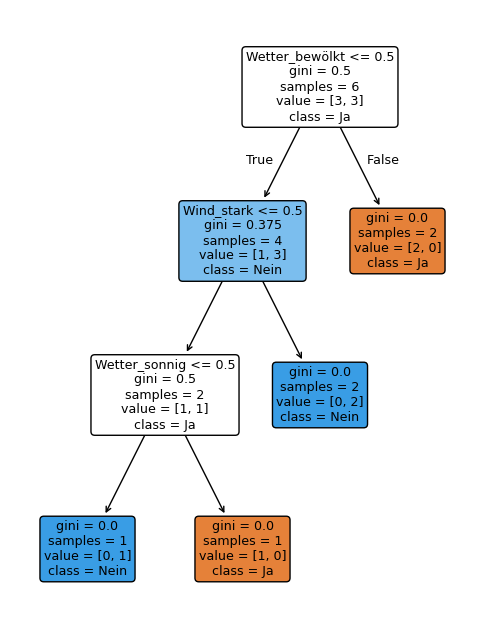

In [4]:
y = df['Spielen']
model = DecisionTreeClassifier(criterion='gini', random_state=0)
model.fit(X, y)

# baum plotten
plt.figure(figsize=(6,8))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=model.classes_,
    filled=True,
    rounded=True
)
plt.show()

<img src='sonnig.png' width='850'>


#### Beispiel 2

In [6]:
data = {
    'Mag Popcorn': ['ja', 'ja', 'nein', 'nein', 'ja', 'ja', 'nein'],
    'Mag Limo': ['ja', 'nein', 'ja', 'ja', 'ja', 'nein', 'nein'],
    'Alter': [7, 12, 18, 35, 38, 50, 83],
    'Mag Film "Cool wie Eis"': ['nein', 'nein', 'ja', 'ja', 'ja', 'nein', 'nein']
}
df = pd.DataFrame(data)
df

,Mag Popcorn,Mag Limo,Alter,"Mag Film ""Cool wie Eis"""
0,ja,ja,7,nein
1,ja,nein,12,nein
2,nein,ja,18,ja
3,nein,ja,35,ja
4,ja,ja,38,ja
5,ja,nein,50,nein
6,nein,nein,83,nein


In [7]:
X = pd.get_dummies(df[['Mag Popcorn', 'Mag Limo', 'Alter']])
y = df['Mag Film "Cool wie Eis"']


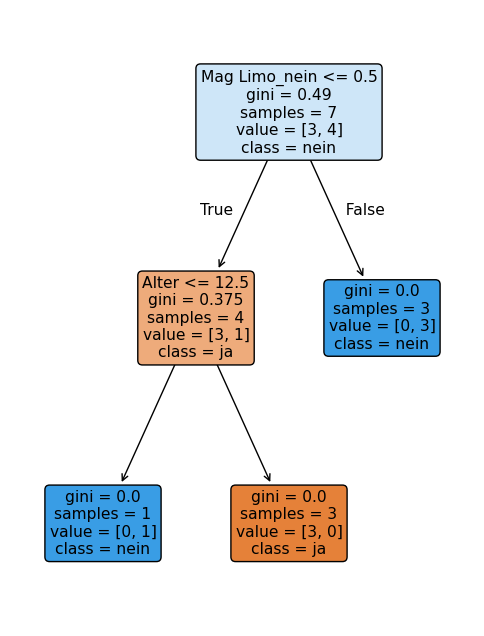

In [8]:
model = DecisionTreeClassifier(criterion='gini', random_state=0)
model.fit(X, y)

# baum plotten
plt.figure(figsize=(6,8))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=model.classes_,
    filled=True,
    rounded=True
)
plt.show()

<img src='split02.png' width='800'>

#### Beispiel 3

Im Titanic-Datensatz bedeuten die Felder:

* **`sibsp`** = *Number of siblings/spouses aboard the Titanic*
  → Gibt an, wie viele Geschwister oder Ehepartner die Person auf dem Schiff dabei hatte.
  Beispiel: `sibsp = 1` bedeutet, dass die Person mit einem Bruder, einer Schwester oder ihrem Ehepartner an Bord war.

* **`parch`** = *Number of parents/children aboard the Titanic*
  → Gibt an, wie viele Eltern oder Kinder die Person dabei hatte.
  Beispiel: `parch = 2` bedeutet, dass die Person mit z. B. Mutter und Vater oder zwei Kindern an Bord war.

* **`embarked`** = *Port of Embarkation*
  → Der Hafen, an dem die Person an Bord gegangen ist:

  * `C` = Cherbourg (Frankreich)
  * `Q` = Queenstown (heute Cobh, Irland)
  * `S` = Southampton (England)

Zusammengenommen kann man mit `sibsp` und `parch` oft die **Familiengröße** an Bord bestimmen (`family_size = sibsp + parch + 1`).




In [9]:
import seaborn as sns
titanic = sns.load_dataset('titanic') 
features = ["sex", "pclass", "age", "sibsp", "parch", "embarked"]
target = "survived"
df = titanic[features + [target]].dropna()
df

,sex,pclass,age,sibsp,parch,embarked,survived
0,male,3,22.0,1,0,S,0
1,female,1,38.0,1,0,C,1
2,female,3,26.0,0,0,S,1
3,female,1,35.0,1,0,S,1
4,male,3,35.0,0,0,S,0
...,...,...,...,...,...,...,...
885,female,3,39.0,0,5,Q,0
886,male,2,27.0,0,0,S,0
887,female,1,19.0,0,0,S,1
889,male,1,26.0,0,0,C,1


In [10]:
X = pd.get_dummies(df[['sex', 'pclass', 'age', 'sibsp','parch','embarked']])
y = df['survived'] 
X.head()

,pclass,age,sibsp,parch,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,3,22.0,1,0,False,True,False,False,True
1,1,38.0,1,0,True,False,True,False,False
2,3,26.0,0,0,True,False,False,False,True
3,1,35.0,1,0,True,False,False,False,True
4,3,35.0,0,0,False,True,False,False,True


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#model = DecisionTreeClassifier(criterion='gini')
model = DecisionTreeClassifier(criterion='gini', max_depth=9)
model.fit(X_train, y_train);


In [12]:
print(f"Train Accuracy: {model.score(X_train, y_train):.2f}")
print(f"Test Accuracy: {model.score(X_test, y_test):.2f}")

Train Accuracy: 0.90
Test Accuracy: 0.85


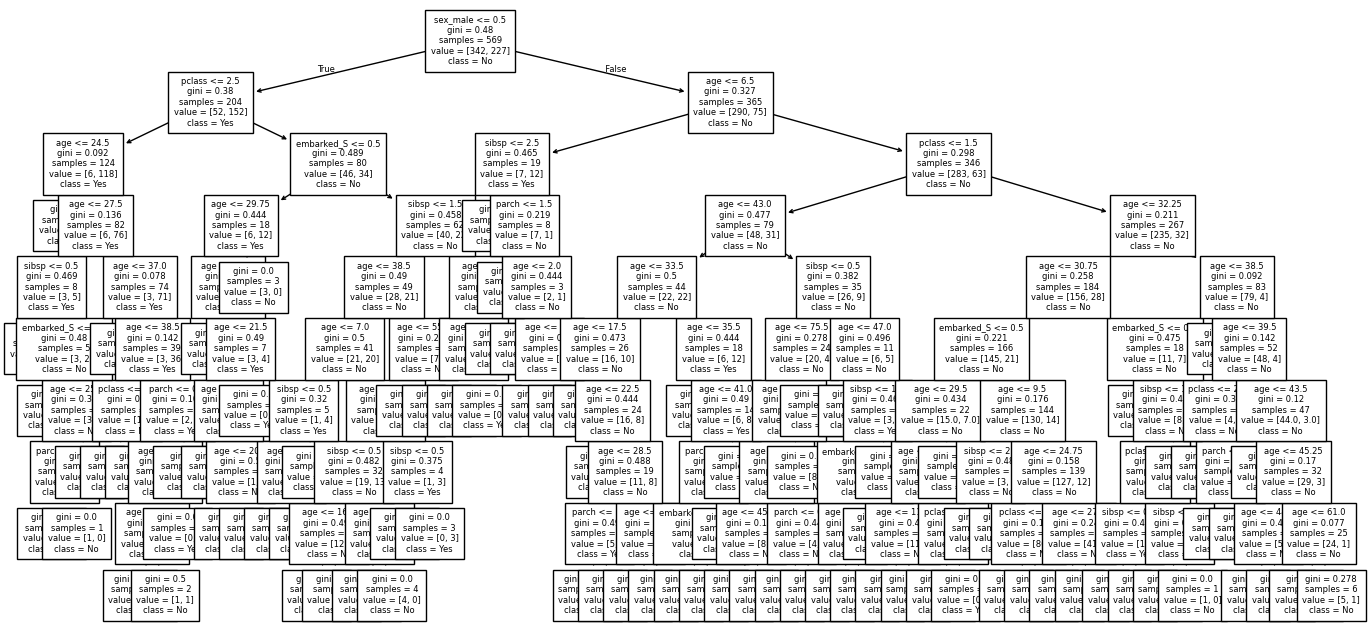

In [13]:
plt.figure(figsize=(17,8))
plot_tree(model,feature_names=list(X.columns),class_names=["No", "Yes"],fontsize=6);

Um Overfitting zu vermeiden können verschiedene Hyperparameter benutzt werden

| Parameter           | What it does                              | Typical values to test  |
| ------------------- | ----------------------------------------- | ----------------------- |
| `max_depth`         | Maximum depth of the tree                 | `None` (no limit), 3–15 |
| `min_samples_split` | Minimum samples to split an internal node | 2, 5, 10, 20            |
| `min_samples_leaf`  | Minimum samples required in a leaf node   | 1, 2, 4, 10             |
| `max_leaf_nodes`    | Limit the number of leaves                | `None`, 5, 10, 20       |
